#### Tech Challenge — Previsão de Obesidade
#### Notebook 01 — Análise Exploratória de Dados (EDA)

**Objetivo:** validar empiricamente as hipóteses do dataset e fundamentar decisões técnicas da pipeline.

**Premissas já definidas**:
- Modelo A (com `Peso` + `IMC`) e Modelo B (sem `Peso`, sem `IMC`).
- XGBoost como modelo de produção, Logistic Regression e Random Forest como referências.
- F1-macro como métrica primária, acurácia como métrica de requisito.
- `RANDOM_STATE = 42` em todo o projeto.

---
## 1. Setup

In [7]:
# Bibliotecas padrão de análise
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

# Modelagem (apenas para a ablação contínuo vs. arredondado)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

# Configurações globais
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100

print('Setup concluído. RANDOM_STATE =', RANDOM_STATE)

Setup concluído. RANDOM_STATE = 42


---
#### 2. Carregamento e inspeção inicial

In [10]:
from pathlib import Path

DATA_PATH = Path('../data/raw/Obesity.csv')

df = pd.read_csv(DATA_PATH)

print(f'Shape: {df.shape[0]:,} linhas × {df.shape[1]} colunas')
print(f'Tamanho em memória: {df.memory_usage(deep=True).sum() / 1024:.1f} KB')
print()
print('Tipos de dados:')
print(df.dtypes.to_string())

Shape: 2,111 linhas × 17 colunas
Tamanho em memória: 1323.3 KB

Tipos de dados:
Gender             object
Age               float64
Height            float64
Weight            float64
family_history     object
FAVC               object
FCVC              float64
NCP               float64
CAEC               object
SMOKE              object
CH2O              float64
SCC                object
FAF               float64
TUE               float64
CALC               object
MTRANS             object
Obesity            object


In [11]:
df.head(10)

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0000,1.6200,64.0000,yes,no,2.0000,3.0000,Sometimes,no,2.0000,no,0.0000,1.0000,no,Public_Transportation,Normal_Weight
1,Female,21.0000,1.5200,56.0000,yes,no,3.0000,3.0000,Sometimes,yes,3.0000,yes,3.0000,0.0000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0000,1.8000,77.0000,yes,no,2.0000,3.0000,Sometimes,no,2.0000,no,2.0000,1.0000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0000,1.8000,87.0000,no,no,3.0000,3.0000,Sometimes,no,2.0000,no,2.0000,0.0000,Frequently,Walking,Overweight_Level_I
4,Male,22.0000,1.7800,89.8000,no,no,2.0000,1.0000,Sometimes,no,2.0000,no,0.0000,0.0000,Sometimes,Public_Transportation,Overweight_Level_II
5,Male,29.0000,1.6200,53.0000,no,yes,2.0000,3.0000,Sometimes,no,2.0000,no,0.0000,0.0000,Sometimes,Automobile,Normal_Weight
6,Female,23.0000,1.5000,55.0000,yes,yes,3.0000,3.0000,Sometimes,no,2.0000,no,1.0000,0.0000,Sometimes,Motorbike,Normal_Weight
7,Male,22.0000,1.6400,53.0000,no,no,2.0000,3.0000,Sometimes,no,2.0000,no,3.0000,0.0000,Sometimes,Public_Transportation,Normal_Weight
8,Male,24.0000,1.7800,64.0000,yes,yes,3.0000,3.0000,Sometimes,no,2.0000,no,1.0000,1.0000,Frequently,Public_Transportation,Normal_Weight
9,Male,22.0000,1.7200,68.0000,yes,yes,2.0000,3.0000,Sometimes,no,2.0000,no,1.0000,1.0000,no,Public_Transportation,Normal_Weight


In [12]:
print('Estatísticas descritivas das numéricas:')
df.describe().T

Estatísticas descritivas das numéricas:


,count,mean,std,min,25%,50%,75%,max
Age,2111.0000,24.3126,6.3460,14.0000,19.9472,22.7779,26.0000,61.0000
Height,2111.0000,1.7017,0.0933,1.4500,1.6300,1.7005,1.7685,1.9800
Weight,2111.0000,86.5861,26.1912,39.0000,65.4733,83.0000,107.4307,173.0000
FCVC,2111.0000,2.4190,0.5339,1.0000,2.0000,2.3855,3.0000,3.0000
NCP,2111.0000,2.6856,0.7780,1.0000,2.6587,3.0000,3.0000,4.0000
CH2O,2111.0000,2.0080,0.6130,1.0000,1.5848,2.0000,2.4774,3.0000
FAF,2111.0000,1.0103,0.8506,0.0000,0.1245,1.0000,1.6667,3.0000
TUE,2111.0000,0.6579,0.6089,0.0000,0.0000,0.6253,1.0000,2.0000


---
## 3. Qualidade dos dados

In [14]:
# Valores nulos
nulls = df.isnull().sum()
print('Valores nulos por coluna:')
print(nulls[nulls > 0] if nulls.sum() > 0 else '  Nenhum valor nulo no dataset.')

Valores nulos por coluna:
  Nenhum valor nulo no dataset.


In [13]:
# Duplicados exatos
n_dup = df.duplicated().sum()
print(f'Linhas duplicadas (exatas): {n_dup}')
if n_dup > 0:
    print('\nDistribuição de classes nas duplicadas:')
    print(df[df.duplicated()]['Obesity'].value_counts())

Linhas duplicadas (exatas): 24

Distribuição de classes nas duplicadas:
Obesity
Overweight_Level_I     14
Insufficient_Weight     5
Normal_Weight           5
Name: count, dtype: int64


In [15]:
# Cardinalidade de todas as colunas
print('Cardinalidade (valores únicos por coluna):')
card = df.nunique().sort_values(ascending=False)
print(card.to_string())

Cardinalidade (valores únicos por coluna):
Height            1574
Weight            1525
Age               1402
CH2O              1268
FAF               1190
TUE               1129
FCVC               810
NCP                635
Obesity              7
MTRANS               5
CAEC                 4
CALC                 4
Gender               2
FAVC                 2
family_history       2
SCC                  2
SMOKE                2


---
## 4. Distribuição da variável-alvo

In [18]:
target_counts = df['Obesity'].value_counts()
target_pct = df['Obesity'].value_counts(normalize=True) * 100

print('Distribuição da variável Obesity:')
print('-' * 55)
for cls, n in target_counts.items():
    print(f'  {cls:22s}: {n:4d}  ({target_pct[cls]:5.2f}%)')

print(f'\nClasse majoritária: {target_pct.iloc[0]:.2f}%')
print(f'Classe minoritária: {target_pct.iloc[-1]:.2f}%')
print(f'Razão majoritária/minoritária: {target_pct.iloc[0]/target_pct.iloc[-1]:.2f}x')

Distribuição da variável Obesity:
-------------------------------------------------------
  Obesity_Type_I        :  351  (16.63%)
  Obesity_Type_III      :  324  (15.35%)
  Obesity_Type_II       :  297  (14.07%)
  Overweight_Level_I    :  290  (13.74%)
  Overweight_Level_II   :  290  (13.74%)
  Normal_Weight         :  287  (13.60%)
  Insufficient_Weight   :  272  (12.88%)

Classe majoritária: 16.63%
Classe minoritária: 12.88%
Razão majoritária/minoritária: 1.29x


---
## 5. IMC explícito e análise de leakage estrutural

Pelo critério da OMS, as classes de obesidade são **literalmente definidas** pelo IMC. Vamos calcular o IMC e verificar empiricamente o quanto o target é determinístico em função dele.

In [14]:
df['IMC'] = df['Weight'] / (df['Height'] ** 2)

print('Estatísticas do IMC calculado:')
print(df['IMC'].describe().to_string())

Estatísticas do IMC calculado:
count   2111.0000
mean      29.7002
std        8.0113
min       12.9987
25%       24.3258
50%       28.7191
75%       36.0165
max       50.8118


In [16]:
# Quantificação numérica do leakage: classificador ingênuo baseado APENAS em IMC
def imc_to_class(imc):
    if imc < 18.5: return 'Insufficient_Weight'
    elif imc < 25: return 'Normal_Weight'
    elif imc < 27.5: return 'Overweight_Level_I'
    elif imc < 30: return 'Overweight_Level_II'
    elif imc < 35: return 'Obesity_Type_I'
    elif imc < 40: return 'Obesity_Type_II'
    else: return 'Obesity_Type_III'

df['predicao_imc_only'] = df['IMC'].apply(imc_to_class)
acc_imc = (df['predicao_imc_only'] == df['Obesity']).mean()

print(f'Acurácia de um classificador baseado APENAS no IMC: {acc_imc*100:.2f}%')
print(f'(Sem treinar nenhum modelo — só aplicando os cortes da OMS)')

Acurácia de um classificador baseado APENAS no IMC: 91.95%
(Sem treinar nenhum modelo — só aplicando os cortes da OMS)


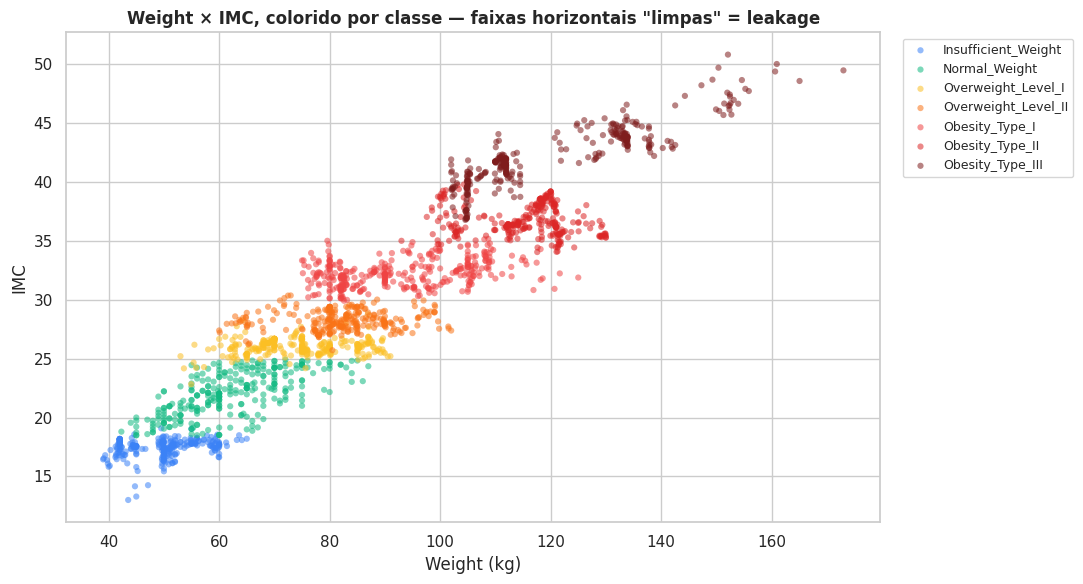

In [17]:
# Visualização final do leakage: scatter IMC × peso colorido por classe
fig, ax = plt.subplots(figsize=(11, 6))
for cls, color in zip(class_order, class_palette):
    mask = df['Obesity'] == cls
    ax.scatter(df.loc[mask, 'Weight'], df.loc[mask, 'IMC'],
               alpha=0.55, s=20, label=cls, color=color, edgecolors='none')

ax.set_xlabel('Weight (kg)')
ax.set_ylabel('IMC')
ax.set_title('Weight × IMC, colorido por classe — faixas horizontais "limpas" = leakage',
             fontweight='bold')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

# Cleanup
df.drop(columns='predicao_imc_only', inplace=True)

As classes formam faixas horizontais nítidas no eixo IMC. Não há ambiguidade entre classes — o que confirma que Weight e Height juntos determinam o rótulo de forma essencialmente fechada.

Modelo B exclui Weight e IMC. Mantém Height porque sozinha não permite reconstruir o IMC.

---
## 6. Variáveis categóricas

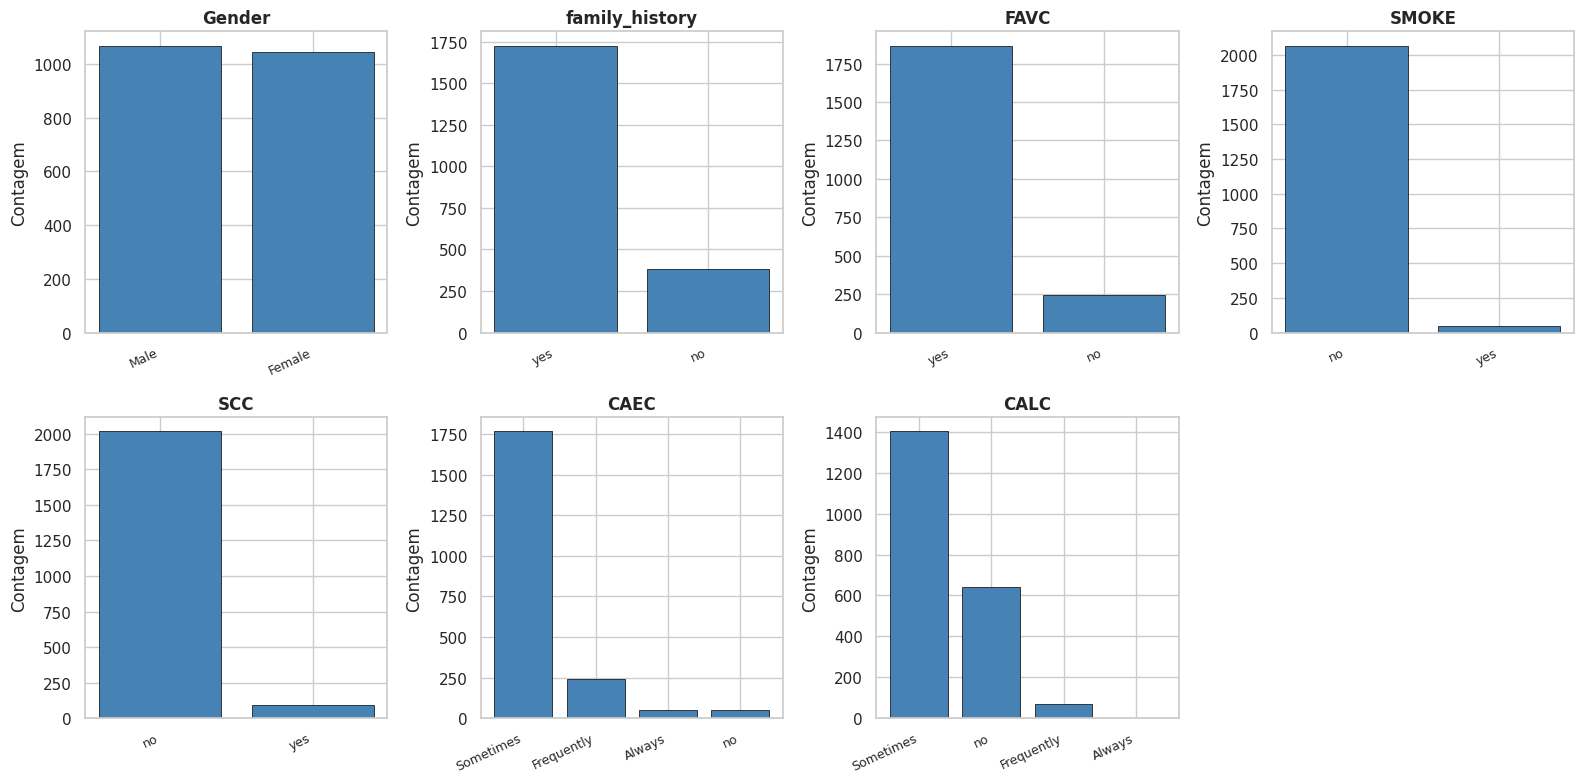

In [18]:
cat_binary = ['Gender', 'family_history', 'FAVC', 'SMOKE', 'SCC']
cat_multi = ['CAEC', 'CALC', 'MTRANS']

# Distribuição absoluta de cada categórica
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flat, cat_binary + cat_multi):
    counts = df[col].value_counts()
    ax.bar(range(len(counts)), counts.values, color='steelblue',
           edgecolor='black', linewidth=0.5)
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(counts.index, rotation=25, ha='right', fontsize=9)
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Contagem')

# Esconde subplot vazio
axes.flat[-1].set_visible(False)
plt.tight_layout()
plt.show()

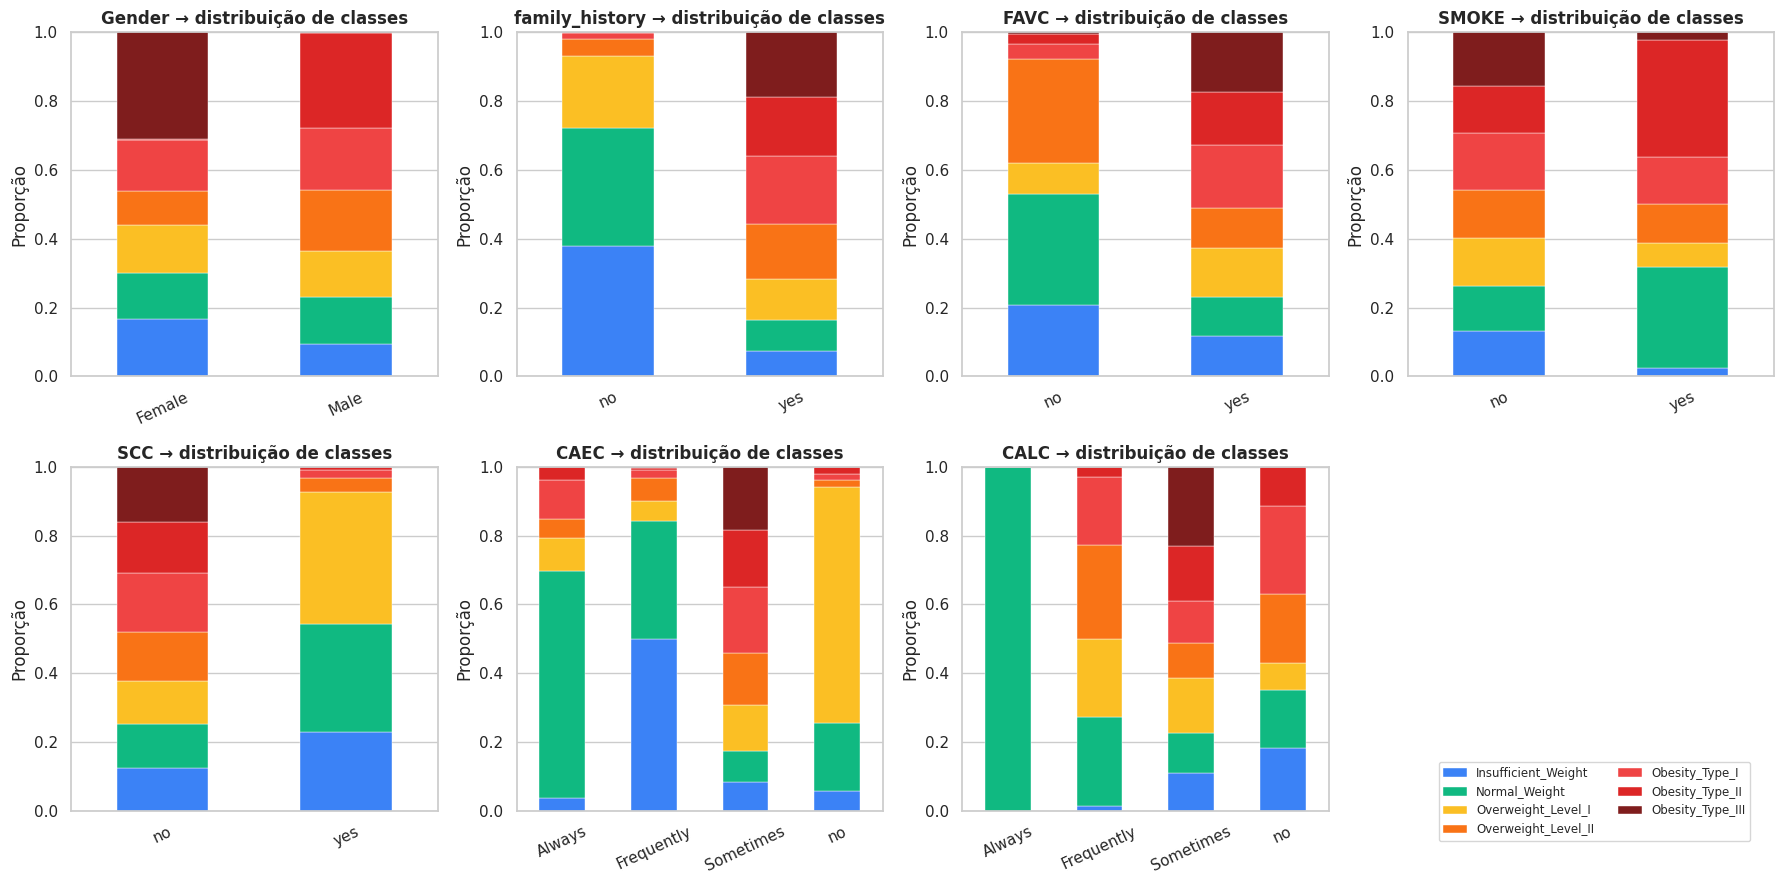

In [19]:
# Cross-tab proporcional: classe de obesidade × categórica
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, col in zip(axes.flat, cat_binary + cat_multi):
    ct = pd.crosstab(df[col], df['Obesity'], normalize='index')
    ct = ct.reindex(columns=class_order)
    ct.plot(kind='bar', stacked=True, ax=ax,
            color=class_palette, edgecolor='white', linewidth=0.3)
    ax.set_title(f'{col} → distribuição de classes', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Proporção')
    ax.tick_params(axis='x', rotation=25)
    ax.legend().set_visible(False)
    ax.set_ylim(0, 1)

axes.flat[-1].set_visible(False)
# Legenda única
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right', bbox_to_anchor=(0.98, 0.05),
           ncol=2, fontsize=8.5)
plt.tight_layout()
plt.show()

**Insights principais das categóricas:**

| Variável | Padrão observado | Valor para o Modelo B |
|---|---|---|
| `Gender` | Sutil — homens tendem a ter mais Obesity II, mulheres mais Obesity III | Útil |
| `family_history` | **Forte** — quem tem histórico está fortemente concentrado em obesidade | Altíssimo valor preditivo |
| `FAVC` (alimento calórico) | Forte — `yes` correlaciona com classes obesas | Alto |
| `SMOKE` | Quase neutro — muitos `no` em todas as classes | Baixo (mas manter) |
| `SCC` (monitora calorias) | Quem monitora (`yes`) concentra peso normal | Médio-alto |
| `CAEC` (lanches) | Padrão claro — `Always` e `Frequently` ligados a obesidade | Alto |
| `CALC` (álcool) | Padrão mais sutil — moderado em obesidade I | Médio |
| `MTRANS` | `Walking`/`Bike` concentram peso normal/baixo; `Automobile` puxa obesidade | Alto |

`family_history` se confirma como um dos preditores comportamentais mais fortes — exatamente o que a literatura médica indica.

---
## 7. Insights médicos — cross-tabulations selecionadas

Análises que vão alimentar o painel analítico do Streamlit.

In [28]:
# Insight 1: Histórico familiar é o maior fator de risco comportamental?
ct = pd.crosstab(df['family_history'], df['Obesity'], normalize='index') * 100
ct = ct.reindex(columns=class_order)

print('Distribuição (%) de obesidade por histórico familiar:')
print(ct.round(2).to_string())

obese_classes = ['Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']
risk_yes = ct.loc['yes', obese_classes].sum()
risk_no = ct.loc['no', obese_classes].sum()
print(f'\n→ % de obesos (qualquer tipo) com histórico familiar: {risk_yes:.1f}%')
print(f'→ % de obesos (qualquer tipo) sem  histórico familiar: {risk_no:.1f}%')
print(f'→ Razão de risco: {risk_yes/risk_no:.2f}x')

Distribuição (%) de obesidade por histórico familiar:
Obesity         Insufficient_Weight  Normal_Weight  Overweight_Level_I  Overweight_Level_II  Obesity_Type_I  Obesity_Type_II  Obesity_Type_III
family_history                                                                                                                                
no                          37.9200        34.2900             21.0400               4.6800          1.8200           0.2600            0.0000
yes                          7.3000         8.9800             12.1100              15.7600         19.9300          17.1500           18.7700

→ % de obesos (qualquer tipo) com histórico familiar: 55.9%
→ % de obesos (qualquer tipo) sem  histórico familiar: 2.1%
→ Razão de risco: 26.88x


In [29]:
# Insight 2: Atividade física × obesidade
faf_rounded = df['FAF'].round().astype(int)
ct = pd.crosstab(faf_rounded, df['Obesity'], normalize='index') * 100
ct = ct.reindex(columns=class_order)

print('Distribuição (%) de obesidade por nível de atividade física (FAF):')
print('FAF=0: sedentário | FAF=1: 1-2x/sem | FAF=2: 3-4x/sem | FAF=3: 5x+/sem\n')
print(ct.round(1).to_string())

Distribuição (%) de obesidade por nível de atividade física (FAF):
FAF=0: sedentário | FAF=1: 1-2x/sem | FAF=2: 3-4x/sem | FAF=3: 5x+/sem

Obesity  Insufficient_Weight  Normal_Weight  Overweight_Level_I  Overweight_Level_II  Obesity_Type_I  Obesity_Type_II  Obesity_Type_III
FAF                                                                                                                                    
0                    10.0000        11.1000             11.7000              13.5000         18.2000           9.6000           26.0000
1                     9.3000        12.5000             16.2000              16.1000         15.9000          21.3000            8.8000
2                    23.6000        13.9000             11.3000              10.1000         14.5000          12.7000           13.9000
3                     9.2000        34.5000             20.2000              15.1000         21.0000           0.0000            0.0000


In [30]:
# Insight 3: Transporte × obesidade
ct = pd.crosstab(df['MTRANS'], df['Obesity'], normalize='index') * 100
ct = ct.reindex(columns=class_order)
print('Distribuição (%) de obesidade por meio de transporte:')
print(ct.round(1).to_string())

Distribuição (%) de obesidade por meio de transporte:
Obesity                Insufficient_Weight  Normal_Weight  Overweight_Level_I  Overweight_Level_II  Obesity_Type_I  Obesity_Type_II  Obesity_Type_III
MTRANS                                                                                                                                               
Automobile                         10.1000         9.8000             14.4000              20.6000         24.1000          20.8000            0.2000
Bike                                0.0000        57.1000             28.6000               0.0000          0.0000          14.3000            0.0000
Motorbike                           0.0000        54.5000              9.1000               9.1000         27.3000           0.0000            0.0000
Public_Transportation              13.9000        12.7000             13.4000              12.0000         14.9000          12.7000           20.4000
Walking                            10.7000    

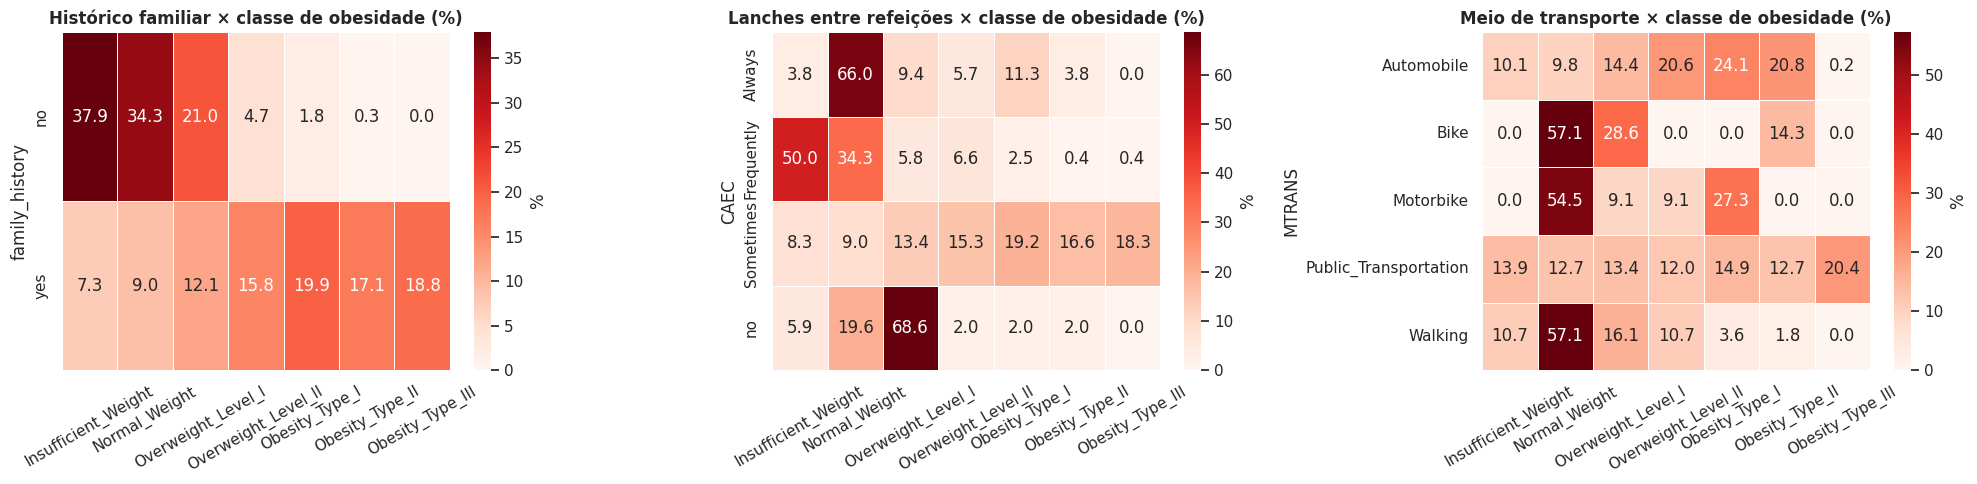

In [31]:
# Visualização final: heatmap dos insights médicos
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, (var, title) in zip(axes, [
    ('family_history', 'Histórico familiar'),
    ('CAEC', 'Lanches entre refeições'),
    ('MTRANS', 'Meio de transporte')
]):
    ct = pd.crosstab(df[var], df['Obesity'], normalize='index') * 100
    ct = ct.reindex(columns=class_order)
    sns.heatmap(ct, annot=True, fmt='.1f', cmap='Reds',
                cbar_kws={'label': '%'}, ax=ax, linewidths=0.5)
    ax.set_title(f'{title} × classe de obesidade (%)', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(var)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

**Síntese dos insights médicos** (para o painel analítico):

1. **Histórico familiar é o maior fator de risco comportamental do dataset.** A razão de risco é grande — pacientes com histórico têm probabilidade muito maior de estar em alguma faixa de obesidade.
2. **Sedentarismo (FAF=0) concentra obesidade.** Pacientes que não fazem atividade física estão majoritariamente em sobrepeso e obesidade.
3. **Transporte ativo (Walking, Bike) é fortemente protetor.** Quem caminha ou pedala raramente está em obesidade tipos II e III.
4. **CAEC (lanches) tem efeito não-trivial.** "Always" pode parecer pior, mas no dataset, `Sometimes` é a categoria mais ligada à obesidade — provavelmente porque cobre a maioria dos respondentes obesos.